In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [27]:
root_folder = "C:/Users/mariana/Downloads/wikiart"

for artist in os.listdir(root_folder):
    artist_path = os.path.join(root_folder, artist)

    if os.path.isdir(artist_path):  #from the folder
        for file in os.listdir(artist_path)[:2]:  # just check a few images on each folder
            img_path = os.path.join(artist_path, file)

            try:
                img = Image.open(img_path)
                arr = np.array(img)

                print(artist, file, arr.dtype, arr.min(), arr.max())

            except Exception as e:
                print("Error with:", img_path, e)

Albrecht_Durer albrecht-durer_a-life-of-the-virgin-1503.jpg uint8 4 200
Albrecht_Durer albrecht-durer_a-nuremberg-costume-study-1500.jpg uint8 0 255
Boris_Kustodiev boris-kustodiev_a-balloon-seller-1915.jpg uint8 0 255
Boris_Kustodiev boris-kustodiev_a-bouquet-of-flowers-on-the-balcony-1924.jpg uint8 0 255
Camille_Pissarro camille-pissarro_a-field-in-varengeville-1899.jpg uint8 0 255
Camille_Pissarro camille-pissarro_a-meadow-in-eragny-1889.jpg uint8 0 255
Childe_Hassam childe-hassam_a-back-road.jpg uint8 0 255
Childe_Hassam childe-hassam_a-country-road.jpg uint8 0 255
Claude_Monet claude-monet_a-corner-of-the-studio(1).jpg uint8 0 255
Claude_Monet claude-monet_a-farmyard-in-normandy(1).jpg uint8 0 255
Edgar_Degas edgar-degas_a-ballet-seen-from-the-opera-box-1885.jpg uint8 0 255
Edgar_Degas edgar-degas_a-carriage-at-the-races-1872.jpg uint8 0 255
Eugene_Boudin eugene-boudin_a-french-port-1884.jpg uint8 0 255
Eugene_Boudin eugene-boudin_a-hen-and-her-chicks-after-melchior-d-hondecoeter.

In [28]:
IMG_SIZE = (224, 224)

In [29]:
rescale = 1.255

Since every artist's images are in 8bit (2^8 = 256 values) format, we can transforms pixel values into [0, 1], where 0 represents no light (black) anbd 1 represents maximum pimentation (white or full colour). For the images that are not black and white, each pixel has 3 values [R, G, B], where each will be scaled from 0 to 1.

| Color | Original        | After scaling |
| ----- | --------------- | ------------- |
| Black | [0, 0, 0]       | [0, 0, 0]     |
| White | [255, 255, 255] | [1, 1, 1]     |
| Red   | [255, 0, 0]     | [1, 0, 0]     |
| Green | [0, 255, 0]     | [0, 1, 0]     |
| Blue  | [0, 0, 255]     | [0, 0, 1]     |
| Gray  | [128,128,128]   | [0.5,0.5,0.5] |

**Apagar mais tarde**

#### First Model

In [30]:
data_generator1 = ImageDataGenerator(rescale=1./255,validation_split=0.3)

In [31]:
print("Training:")
X_train = data_generator.flow_from_directory(
    "C:/Users/mariana/Downloads/wikiart",
    target_size = IMG_SIZE,
    batch_size = 32, # so it isn't slower
    class_mode = 'categorical',
    subset = 'training'
)
print("Validation:")
X_val = data_generator.flow_from_directory(
    "C:/Users/mariana/Downloads/wikiart",
    target_size = IMG_SIZE,
    batch_size = 32,
    class_mode = 'categorical',
    subset = 'validation'
)

Training:
Found 9004 images belonging to 23 classes.
Validation:
Found 3844 images belonging to 23 classes.


In [32]:
model1 = models.Sequential([ # using the Sequential model
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)), # each layer looks at 32 caracteristics 
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64, (3,3), activation='relu'), # after getting the result from 32 filters, 64 filters will detect more complex characteristics
    layers.MaxPooling2D(2,2), # takes the max value of each 2×2 region

    layers.Flatten(), # to get 1D vector to be processed by the Dense layers
    layers.Dense(128, activation='relu'), # Dense is used to combine the previous results
    layers.Dense(X_train.num_classes, activation='softmax')
])

In [33]:
model1.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

testing1 = model1.fit(
    X_train,
    validation_data = X_val,
    epochs = 10
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 228s 806ms/step - accuracy: 0.1637 - loss: 3.0857 - val_accuracy: 0.2261 - val_loss: 2.6327
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 259s 918ms/step - accuracy: 0.2869 - loss: 2.4182 - val_accuracy: 0.3434 - val_loss: 2.3171
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 262s 929ms/step - accuracy: 0.4538 - loss: 1.8562 - val_accuracy: 0.3223 - val_loss: 2.3434
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 251s 891ms/step - accuracy: 0.6885 - loss: 1.0584 - val_accuracy: 0.3309 - val_loss: 2.7243
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 257s 911ms/step - accuracy: 0.8861 - loss: 0.4082 - val_accuracy: 0.3390 - val_loss: 3.6483
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 256s 909ms/step - accuracy: 0.9571 - loss: 0.1756 - val_accuracy: 0.3189 - val_loss: 4.0255
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 262s 929ms/step - accuracy: 0.9835 - loss: 0.0702 - val_accuracy: 0.3189 - val_loss: 4.7438
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 263s 931ms/step - accuracy: 0.9839 -

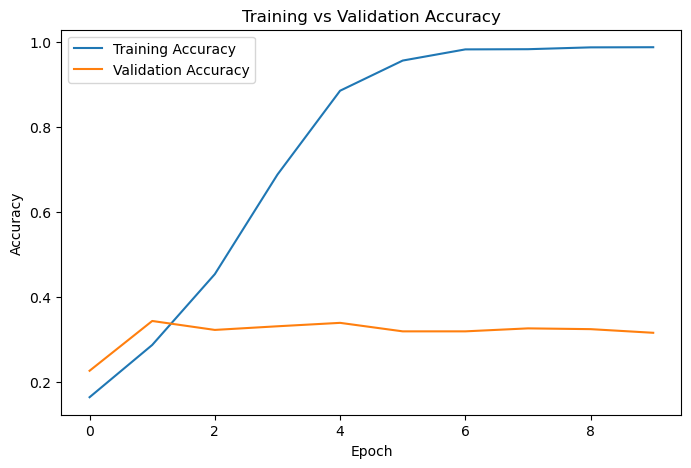

In [34]:
# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(testing1.history['accuracy'], label='Training Accuracy')
plt.plot(testing1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

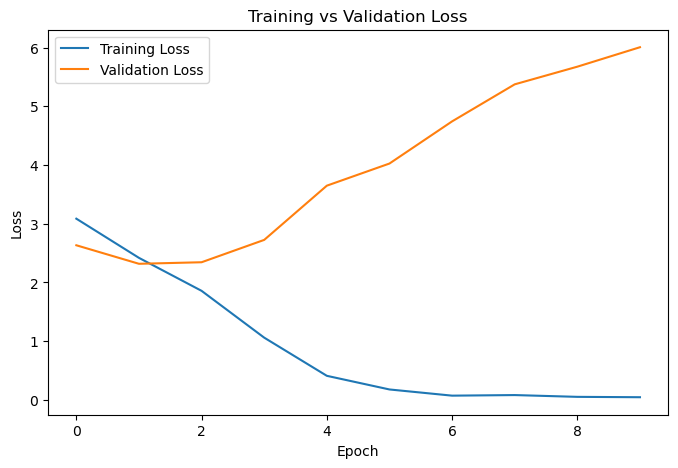

In [42]:
# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(testing1.history['loss'], label='Training Loss')
plt.plot(testing1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

#### Second Model

In [36]:
data_generator2 = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1
)

In [37]:
model2 = models.Sequential([ # using the Sequential model
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)), # each layer looks at 32 caracteristics 
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64, (3,3), activation='relu'), # after getting the result from 32 filters, 64 filters will detect more complex characteristics
    layers.MaxPooling2D(2,2), # takes the max value of each 2×2 region

    layers.Flatten(), # to get 1D vector to be processed by the Dense layers
    layers.Dense(128, activation='relu'), # Dense is used to combine the previous results
    layers.Dense(X_train.num_classes, activation='softmax')
])

In [38]:
model2.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

testing2 = model2.fit(
    X_train,
    validation_data = X_val,
    epochs = 10
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.1908 - loss: 2.9102 - val_accuracy: 0.2586 - val_loss: 2.4911
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 232s 823ms/step - accuracy: 0.3024 - loss: 2.3304 - val_accuracy: 0.2898 - val_loss: 2.4075
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 186s 661ms/step - accuracy: 0.4736 - loss: 1.7587 - val_accuracy: 0.3369 - val_loss: 2.3257
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 205s 728ms/step - accuracy: 0.7407 - loss: 0.8949 - val_accuracy: 0.3411 - val_loss: 2.7685
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 214s 759ms/step - accuracy: 0.9129 - loss: 0.3127 - val_accuracy: 0.3325 - val_loss: 3.7129
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 214s 760ms/step - accuracy: 0.9677 - loss: 0.1290 - val_accuracy: 0.3148 - val_loss: 4.1641
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 215s 764ms/step - accuracy: 0.9891 - loss: 0.0551 - val_accuracy: 0.3158 - val_loss: 4.8107
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 217s 768ms/step - accuracy: 0.9971 - lo

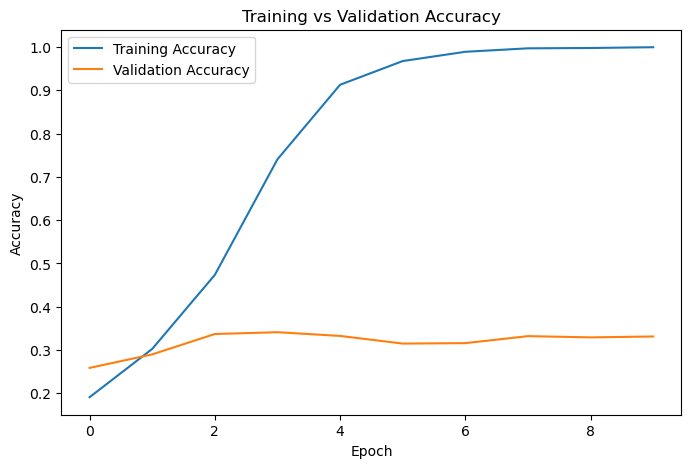

In [39]:
# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(testing2.history['accuracy'], label='Training Accuracy')
plt.plot(testing2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

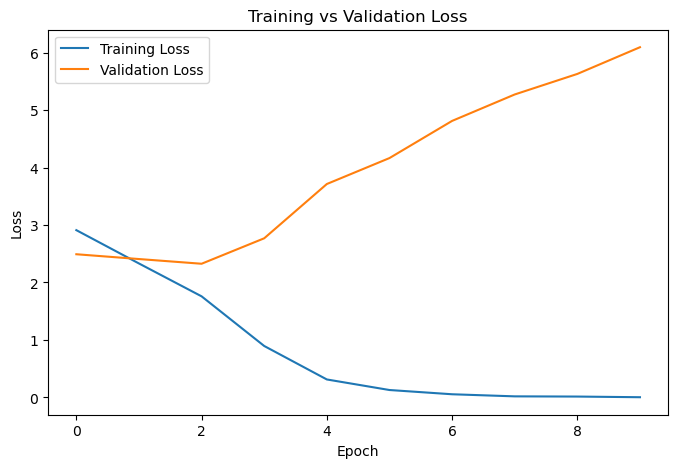

In [41]:
# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(testing2.history['loss'], label='Training Loss')
plt.plot(testing2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()